# Economics 5040: Dynamic Stochastic Modeling
## Problem Set 1 — Starter Notebook
### Intertemporal Choice, Production, and Equilibrium

Use this notebook to organize your derivations, code, figures, numerical answers, and economic explanations.

You may add as many Markdown and code cells as you need.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar, brentq


# Problem 1. Utility, Rankings, and Intertemporal Preferences

Consider
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$


### (a)
Define the utility function, evaluate plans A, B, and C, and rank them.

In [2]:
beta = 0.95

def U(c0, c1, beta=beta):
    return np.log(c0) + beta * np.log(c1)

A = (4.0, 4.0)
B = (3.0, 6.0)
C = (5.0, 3.0)

# evaluate the three plans
valA = U(A[0], A[1], beta)
valB = U(B[0], B[1], beta)
valC = U(C[0], C[1], beta)

print(f"U(A) = {valA:.6f}")
print(f"U(B) = {valB:.6f}")
print(f"U(C) = {valC:.6f}")

# rank them
order = sorted([("A", valA), ("B", valB), ("C", valC)], key=lambda p: -p[1])
print("Ranking:", " > ".join(name for name, _ in order))

U(A) = 2.703274
U(B) = 2.800784
U(C) = 2.653120
Ranking: B > A > C


### (b)
Define the monotone transformation $V(c_0,c_1)=\exp(U(c_0,c_1))$. Verify that the ranking is unchanged and explain why.

In [3]:
def V(c0, c1, beta=beta):
    return np.exp(U(c0, c1, beta))

# evaluate V for A, B, and C
vA = V(A[0], A[1], beta)
vB = V(B[0], B[1], beta)
vC = V(C[0], C[1], beta)

print(f"V(A) = {vA:.6f}")
print(f"V(B) = {vB:.6f}")
print(f"V(C) = {vC:.6f}")

orderV = sorted([("A", vA), ("B", vB), ("C", vC)], key=lambda p: -p[1])
print("Ranking:", " > ".join(name for name, _ in orderV))

V(A) = 14.928528
V(B) = 16.457541
V(C) = 14.198262
Ranking: B > A > C


Same ranking, $B \succ A \succ C$. $\exp(\cdot)$ is strictly increasing, so $U(x) > U(y)$ if and only if $V(x) > V(y)$ — a monotone transformation relabels the utility numbers but leaves the ordering they encode untouched. Utility is ordinal here: only the ranking has meaning, not the levels or the differences.

### (c)
Create a grid of at least 10,000 positive bundles. Verify numerically that $U$ and $V$ induce the same ranking.

In [4]:
grid = np.linspace(0.25, 10.0, 100)

# 1. create a meshgrid of (c0, c1) bundles
meshgrid = np.meshgrid(grid, grid)

# 2. evaluate U and V on the whole grid
U_vals = U(meshgrid[0], meshgrid[1], beta)
V_vals = V(meshgrid[0], meshgrid[1], beta)

# 3. verify that the orderings agree
rankU = np.argsort(U_vals, axis=None)
rankV = np.argsort(V_vals, axis=None)

print(rankU)
print(np.array_equal(rankU, rankV))



[   0  100    1 ... 9998 9899 9999]
True


### (d)

For
$$
U(c_0,c_1,c_2)=\log c_0+\beta\log c_1+\beta^2\log c_2,
$$
derive the MRS between $c_1$ and $c_2$. Explain why $c_0$ does not appear and what this says about time-separable preferences.


### Marginal Rate of Substitution (MRS) between $c_1$ and $c_2$

given,
$$
U(c_0, c_1, c_2) = \log c_0 + \beta \log c_1 + \beta^2 \log c_2.
$$

between c1 & c2:
$$
MRS_{1,2} = \frac{\partial U/\partial c_2}{\partial U/\partial c_1}.
$$

the partial derivatives are:
$$
\frac{\partial U}{\partial c_1} = \frac{\beta}{c_1},
\qquad
\frac{\partial U}{\partial c_2} = \frac{\beta^2}{c_2}.
$$

and thus,
$$
MRS_{1,2}
= \frac{\beta^2/c_2}{\beta/c_1}
= \frac{\beta^2}{c_2} \cdot \frac{c_1}{\beta}
= \frac{\beta c_1}{c_2}.
$$



$c_0$ does not appear in the MRS between $c_1$ and $c_2$ because the utility function is additively separable across periods, and preferences are time-separable. The tradeoff between $c_1$ and $c_2$ depends only on those two marginal utilities, not on the level of $c_0$.


# Problem 2. A Two-Period Exchange Economy

Endowment:
$$
(e_0,e_1)=(4,6)
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.96.
$$


In [5]:
e0 = 4.0
e1 = 6.0
beta2 = 0.96

### (a)
Write the present-value budget constraint and derive its slope. Explain the interpretation of $R$.

The present-value (PV) budget constraint equates the present value of consumption to the present value of endowments:
$$
c_0 + \frac{c_1}{R} = e_0 + \frac{e_1}{R}.
$$

The slope of the budget constraint is found by solving for $c_1$ in terms of $c_0$:
$$
c_1 = R \left[ \left( e_0 + \frac{e_1}{R} \right) - c_0 \right].
$$
This has slope $-R$: for each additional unit of $c_0$ consumed today, the agent must forgo $R$ units of future consumption $c_1$.

$R$ is the gross interest rate. It is the opportunity cost of consuming today rather than tomorrow: consuming one more unit today requires giving up $R$ units of consumption tomorrow. When $R>1$, future consumption is more expensive in terms of today's resources.


### (b)
Set $R=1.10$. Solve analytically, then solve numerically. Report $c_0^*,c_1^*$, saving, and the MRS check.

In [6]:
R = 1.10

# Present-value wealth
# wealth = e0 + e1/R
W = e0 + e1/R

# Analytical solution
# The FOC: 1/c0 = beta*R/c1. Budget: c0 + c1/R = W
# Solve FOC for c1: c1 = beta*R*c0
# Plug into budget: c0 + (beta*R*c0)/R = W => c0 + beta*c0 = W => c0*(1 + beta) = W
c0_star = W / (1 + beta2)
c1_star = beta2 * R * c0_star
saving = e0 - c0_star

print(f"Analytical solution:")
print(f"  c0* = {c0_star:.4f}")
print(f"  c1* = {c1_star:.4f}")
print(f"  Saving = {saving:.4f}")
print(f"  MRS = c1/c0 = {c1_star/c0_star:.4f}, beta*R = {beta2*R:.4f}")

def objective(c0):
    # Given c0, infer c1 from the budget constraint
    c1 = R * (W - c0)
    if c0 <= 0.0 or c1 <= 0.0:
        return np.inf
    # Return negative utility for minimization (use beta2, not the Problem 1 default)
    return -U(c0, c1, beta2)

# Numerical solution using minimize_scalar
res = minimize_scalar(objective, bounds=(1e-10, W - 1e-10), method="bounded")
c0_num = res.x
c1_num = R * (W - c0_num)
s_num = e0 - c0_num

print("\nNumerical solution:")
print(f"  c0_num = {c0_num:.6f}")
print(f"  c1_num = {c1_num:.6f}")
print(f"  Saving = {s_num:.6f}")
print(f"  |c0_num - c0*| = {abs(c0_num - c0_star):.3e}")
print(f"  |c1_num - c1*| = {abs(c1_num - c1_star):.3e}")
print(f"  MRS check: c1/(beta*c0) = {c1_num / (beta2 * c0_num):.10f}  vs  R = {R:.10f}")


Analytical solution:
  c0* = 4.8237
  c1* = 5.0939
  Saving = -0.8237
  MRS = c1/c0 = 1.0560, beta*R = 1.0560

Numerical solution:
  c0_num = 4.823748
  c1_num = 5.093878
  Saving = -0.823748
  |c0_num - c0*| = 4.464e-08
  |c1_num - c1*| = 4.911e-08
  MRS check: c1/(beta*c0) = 1.0999999792  vs  R = 1.1000000000


### (c)
Plot the endowment, budget line, budget set, optimum, and indifference curve through the optimum.

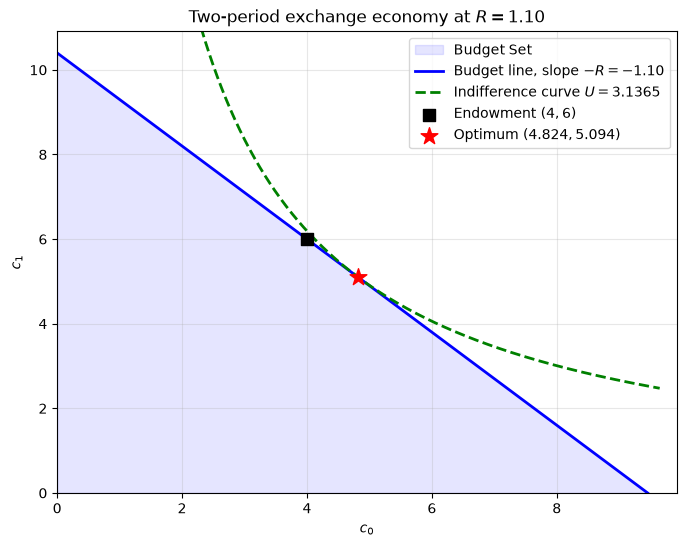

In [7]:
# Budget line: c1 = R (W - c0), for c0 in [0, W]
c0_line = np.linspace(0, W, 500)
c1_budget = R * (W - c0_line)

# Separate, economically relevant grid for the indifference curve
# so the log-utility asymptote near c0=0 does not distort the graph.
utility_star = U(c0_star, c1_star, beta2)
c0_indiff = np.linspace(0.35 * c0_star, 2.0 * c0_star, 600)
c1_indiff = np.exp((utility_star - np.log(c0_indiff)) / beta2)

# Axis limits from the budget intercepts (not from the IC)
c0_max = W * 1.05
c1_max = R * W * 1.05

plt.figure(figsize=(8, 6))
plt.fill_between(c0_line, 0, c1_budget, color="blue", alpha=0.10, label="Budget Set")
plt.plot(c0_line, c1_budget, color="blue", lw=2, label=rf"Budget line, slope $-R=-{R:.2f}$")
plt.plot(c0_indiff, c1_indiff, color="green", ls="--", lw=2, label=rf"Indifference curve $U={utility_star:.4f}$")
plt.scatter([e0], [e1], color="black", marker="s", s=80, zorder=5,
            label=rf"Endowment $({e0:.0f},{e1:.0f})$")
plt.scatter([c0_star], [c1_star], color="red", marker="*", s=160, zorder=5,
            label=rf"Optimum $({c0_star:.3f},{c1_star:.3f})$")

plt.xlim(0, c0_max)
plt.ylim(0, c1_max)
plt.xlabel(r"$c_0$")
plt.ylabel(r"$c_1$")
plt.title(rf"Two-period exchange economy at $R={R:.2f}$")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()


### (d)
Solve the problem for 100 values of $R\in[0.8,1.5]$. Plot $c_0^*(R)$, $c_1^*(R)$, and saving. Explain income and substitution effects.

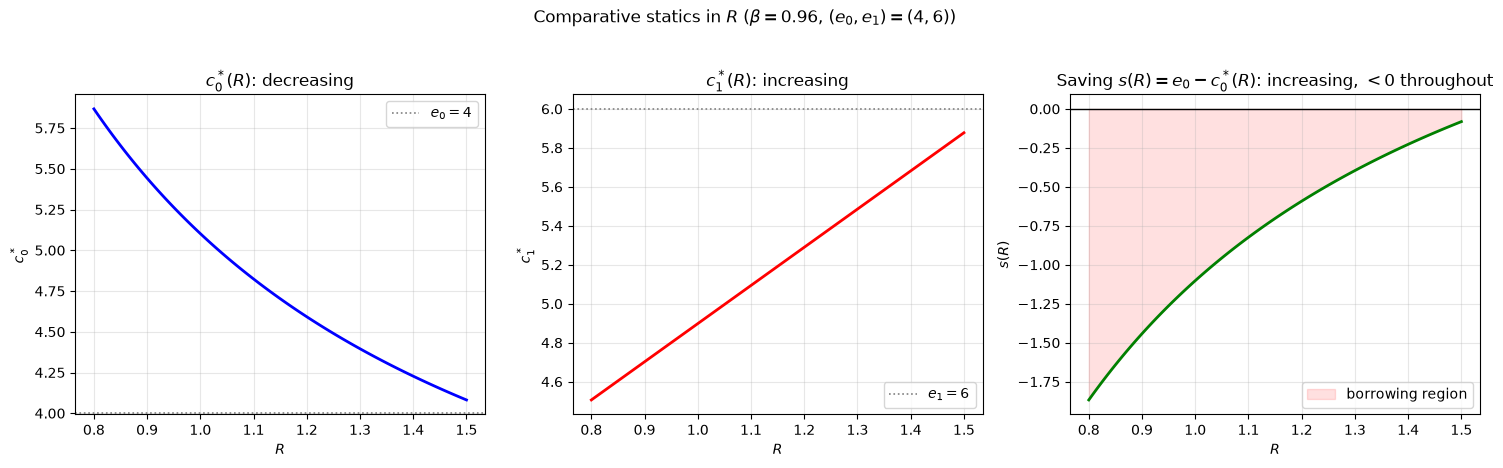

     R         W       c0*       c1*         s
  0.80   11.5000    5.8673    4.5061   -1.8673
  1.00   10.0000    5.1020    4.8980   -1.1020
  1.10    9.4545    4.8237    5.0939   -0.8237
  1.50    8.0000    4.0816    5.8776   -0.0816

saving is negative at every R on the grid: True
R at which s = 0 (outside this grid): R_hat = e1/(beta*e0) = 1.5625


In [8]:
R_grid = np.linspace(0.8, 1.5, 100)

# Compute c0*(R), c1*(R), and s(R).
# Loop over Rv, not R, so the global R = 1.10 from parts (b)-(c) is not overwritten.
c0_star_r = []
c1_star_r = []
s_r = []

for Rv in R_grid:
    Wv = e0 + e1 / Rv                 # present-value wealth at this R
    c0_v = Wv / (1 + beta2)           # c0* = W/(1+beta)
    c1_v = beta2 * Rv * c0_v          # c1* = beta*R*c0*
    c0_star_r.append(c0_v)
    c1_star_r.append(c1_v)
    s_r.append(e0 - c0_v)             # saving = e0 - c0*

c0_star_r = np.array(c0_star_r)
c1_star_r = np.array(c1_star_r)
s_r = np.array(s_r)

# Make the three plots
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

ax[0].plot(R_grid, c0_star_r, lw=2, color="blue")
ax[0].axhline(e0, color="gray", ls=":", lw=1.2, label=rf"$e_0={e0:.0f}$")
ax[0].set_ylabel(r"$c_0^*$")
ax[0].set_title(r"$c_0^*(R)$: decreasing")
ax[0].legend()

ax[1].plot(R_grid, c1_star_r, lw=2, color="red")
ax[1].axhline(e1, color="gray", ls=":", lw=1.2, label=rf"$e_1={e1:.0f}$")
ax[1].set_ylabel(r"$c_1^*$")
ax[1].set_title(r"$c_1^*(R)$: increasing")
ax[1].legend()

ax[2].plot(R_grid, s_r, lw=2, color="green")
ax[2].axhline(0, color="black", lw=1)
ax[2].fill_between(R_grid, s_r, 0, where=s_r < 0, color="red", alpha=0.12,
                   label="borrowing region")
ax[2].set_ylabel(r"$s(R)$")
ax[2].set_title(r"Saving $s(R)=e_0-c_0^*(R)$: increasing, $<0$ throughout")
ax[2].legend()

for a in ax:
    a.set_xlabel(r"$R$")
    a.grid(True, alpha=0.3)

fig.suptitle(rf"Comparative statics in $R$ ($\beta={beta2}$, $(e_0,e_1)=({e0:.0f},{e1:.0f})$)", y=1.03)
fig.tight_layout()
plt.show()

# Report a few values
print(f"{'R':>6}{'W':>10}{'c0*':>10}{'c1*':>10}{'s':>10}")
for Rv in (0.8, 1.0, 1.1, 1.5):
    Wv = e0 + e1 / Rv
    c0_v = Wv / (1 + beta2)
    print(f"{Rv:>6.2f}{Wv:>10.4f}{c0_v:>10.4f}{beta2 * Rv * c0_v:>10.4f}{e0 - c0_v:>10.4f}")

print(f"\nsaving is negative at every R on the grid: {bool(np.all(s_r < 0))}")
print(f"R at which s = 0 (outside this grid): R_hat = e1/(beta*e0) = {e1 / (beta2 * e0):.4f}")


### Income and substitution effects

A higher $R$ pivots the budget line about the endowment $(4,6)$, making it steeper. With $c_0^*=\frac{e_0+e_1/R}{1+\beta}$ and $c_1^*=\frac{\beta(Re_0+e_1)}{1+\beta}$:

- **Substitution:** one unit of $c_0$ costs $R$ units of $c_1$, so a higher $R$ shifts consumption from $c_0$ to $c_1$. Log utility has an intertemporal elasticity of $1$, so this effect is strong.
- **Income:** $dR$ slackens the budget by $\frac{s}{R}dR$, so it carries the sign of saving — a lender gains, a borrower loses. Panel 3 shows $s<0$ on the whole grid, so it is negative here.

**Panel 1** ($c_0^*$: $5.8673\to4.0816$). Both effects push $c_0$ down, so the decline is unambiguous.

**Panel 2** ($c_1^*$: $4.5061\to5.8776$). The effects conflict; substitution wins. Exactly linear in $R$.

**Panel 3** ($s$: $-1.8673\to-0.0816$). Saving rises toward zero but stays negative, reaching $s=0$ only at $\widehat R=e_1/(\beta e_0)=1.5625$ — just past the grid, so she borrows throughout.

This tidiness comes from the future-weighted endowment ($e_1>e_0$). For a lender the two effects on $c_0$ would oppose each other and the sign of $dc_0^*/dR$ would be ambiguous.

### (e)
Find numerically and analytically the value $\widehat R$ at which the consumer chooses the endowment exactly. Interpret it.

In [9]:
# The consumer picks the endowment exactly when saving is zero, so root-find on s(R).
def saving_at_R(Rv):
    Wv = e0 + e1 / Rv
    return e0 - Wv / (1 + beta2)

R_hat = brentq(saving_at_R, 0.5, 5.0)
R_hat_closed = e1 / (beta2 * e0)

print(f"closed form                 R_hat = {R_hat_closed:.12f}")
print(f"brentq on s(R)              R_hat = {R_hat:.12f}")

# same thing the slow way: re-solve the consumer's problem numerically at each R
def saving_numeric(Rv):
    Wv = e0 + e1 / Rv
    obj = lambda c0: np.inf if (c0 <= 0 or Wv - c0 <= 0) else -U(c0, Rv * (Wv - c0), beta2)
    return e0 - minimize_scalar(obj, bounds=(1e-10, Wv - 1e-10), method="bounded").x

print(f"brentq + minimize_scalar    R_hat = {brentq(saving_numeric, 0.5, 5.0):.12f}")

W_hat = e0 + e1 / R_hat
print(f"\nat R_hat: W = {W_hat:.4f}, c0 = {W_hat/(1+beta2):.6f}, "
      f"c1 = {beta2*R_hat*W_hat/(1+beta2):.6f}, s = {saving_at_R(R_hat):.3e}")


closed form                 R_hat = 1.562500000000
brentq on s(R)              R_hat = 1.562500000000
brentq + minimize_scalar    R_hat = 1.562500029523

at R_hat: W = 7.8400, c0 = 4.000000, c1 = 6.000000, s = 0.000e+00


### (e) Answer

**Analytical:** The endowment is chosen exactly when $s=0$, i.e. $c_0^*=e_0$. Setting $c_0^*=\frac{W}{1+\beta}=e_0$,

$$
e_0+\frac{e_1}{R}=(1+\beta)e_0
\;\Longrightarrow\;
\frac{e_1}{R}=\beta e_0
\;\Longrightarrow\;
\widehat R=\frac{e_1}{\beta e_0}=\frac{6}{0.96\times 4}=1.5625,
\qquad \hat r=56.25\%.
$$

Equivalently, $\widehat R$ is the $MRS$ evaluated *at the endowment*: $\dfrac{e_1}{\beta e_0}=\widehat R$.

**Numerical:** Root of $s(R)=e_0-c_0^*(R)$ via `brentq` on the bracket $[0.5,\,5.0]$:

| method | $\widehat R$ |
|---|---|
| closed form | $1.562500000000$ |
| `brentq` on $s(R)$ | $1.562500000000$ |
| `brentq` re-solving `minimize_scalar` at each $R$ | $1.562500029523$ |

At $\widehat R$: $W=7.84$, $c_0^*=4.0000=e_0$, $c_1^*=6.0000=e_1$, $s=0$.

**Interpretation:**

- **Autarky rate:** $\widehat R$ is the rate at which the agent is exactly indifferent at the margin between borrowing and lending, so she trades nothing. Geometrically, the budget line is tangent to the indifference curve *at the endowment point*.
- **Two forces:** $\widehat R=\underbrace{1/\beta}_{1.0417}\times\underbrace{e_1/e_0}_{1.5}$: impatience requires compensation for waiting, and a growing endowment means she is already rich tomorrow, so diminishing marginal utility demands a high return to add still more.
- **Sorting threshold:** $R<\widehat R\Rightarrow$ she borrows; $R>\widehat R\Rightarrow$ she lends. Since $\widehat R=1.5625$ lies above the entire grid $[0.8,1.5]$ of part (d), she borrows everywhere in that figure.
- **Equilibrium reading:** In a closed one-agent endowment economy, market clearing requires $s=0$. So $\widehat R$ *is* the general-equilibrium interest rate: the price adjusts until desired trade is zero when there is no one to trade with.

# Problem 3. Intertemporal Production and the Planner

$$
y_0=10,\qquad
c_0+k_0=y_0,
$$
and
$$
c_1=f(k_0)=A k_0^\alpha,
\qquad
A=2.5,\quad \alpha=0.4.
$$

Preferences:
$$
U(c_0,c_1)=\log c_0+\beta\log c_1,
\qquad \beta=0.95.
$$


In [10]:
y0 = 10.0
Aprod = 2.5
alpha = 0.4
beta3 = 0.95

def f(k):
    return Aprod * k ** alpha

def fprime(k):
    return Aprod * alpha * k ** (alpha - 1.0)

### (a)
Write the planner's problem with all choice variables and constraints. Then reduce it to a one-variable problem in $k_0$.

The planner chooses $(c_0, c_1, k_0)$ to
$$
\max\ \log c_0 + \beta \log c_1
\qquad \text{s.t.}\qquad
c_0 + k_0 = y_0, \qquad c_1 = f(k_0) = A k_0^\alpha,
$$
with $c_0, c_1 > 0$ and $0 \le k_0 \le y_0$.

Both constraints bind: utility is strictly increasing in both goods, so wasting resources is never optimal. That leaves one genuine choice variable, $k_0$ — whatever is not invested is eaten today, and whatever is produced is eaten tomorrow. Substituting both constraints in,

$$
\max_{0 < k_0 < y_0}\ G(k_0) = \log(y_0 - k_0) + \beta \log\!\left(A k_0^\alpha\right)
= \log(y_0 - k_0) + \alpha\beta \log k_0 + \beta \log A.
$$

$G$ is strictly concave on $(0, y_0)$ and goes to $-\infty$ at both endpoints, so the maximizer is interior and unique. The $\beta \log A$ term is just an additive constant, so $A$ will not affect the choice of $k_0$.

### (b)
Derive the planner's first-order condition and show that $MRS=MRT$.

Differentiating $G$:
$$
G'(k_0) = -\frac{1}{y_0 - k_0} + \beta \frac{f'(k_0)}{f(k_0)} = 0
\qquad \Longleftrightarrow \qquad
\frac{1}{c_0} = \beta \frac{f'(k_0)}{c_1},
$$
which is the Euler equation with the marginal product of capital playing the role of the return on saving.

Rearranging gives the marginal rate of substitution:
$$
MRS_{0,1} = \frac{\partial U/\partial c_0}{\partial U/\partial c_1} = \frac{1/c_0}{\beta/c_1} = \frac{c_1}{\beta c_0} = f'(k_0).
$$

The production possibility frontier is $c_1 = f(y_0 - c_0)$, so its slope is $-f'(y_0 - c_0) = -f'(k_0)$, i.e. $MRT_{0,1} = f'(k_0)$. Therefore
$$
MRS_{0,1} = \frac{c_1}{\beta c_0} = f'(k_0) = MRT_{0,1}.
$$

$MRS$ is the rate at which the household is *willing* to give up today for tomorrow; $MRT$ is the rate at which the technology *can*. If $MRS > MRT$ the planner should invest less, if $MRS < MRT$ more. At the optimum they are equal, which is exactly the statement that the indifference curve is tangent to the PPF.

### (c)
Solve analytically for $k_0^*,c_0^*,c_1^*$. Then solve numerically and compare.

With Cobb–Douglas, $f'(k)/f(k) = \alpha/k$, so the FOC collapses to
$$
\frac{1}{y_0 - k_0} = \frac{\alpha\beta}{k_0}
\qquad \Longrightarrow \qquad
k_0^* = \frac{\alpha\beta}{1 + \alpha\beta}\, y_0,
\qquad
c_0^* = \frac{y_0}{1 + \alpha\beta},
\qquad
c_1^* = A (k_0^*)^\alpha.
$$

The investment rate $k_0^*/y_0 = \alpha\beta/(1+\alpha\beta)$ depends only on $\alpha$ and $\beta$, not on $A$.

In [11]:
# Analytical
k_star = alpha * beta3 * y0 / (1 + alpha * beta3)
c0_star3 = y0 - k_star
c1_star3 = f(k_star)
U_star3 = U(c0_star3, c1_star3, beta3)

print("Analytical solution:")
print(f"  k0* = {k_star:.6f}   (investment rate {k_star/y0:.4%})")
print(f"  c0* = {c0_star3:.6f}")
print(f"  c1* = {c1_star3:.6f}")
print(f"  U   = {U_star3:.6f}")

def planner_objective(k):
    # Everything reduces to k: c0 = y0 - k and c1 = f(k)
    if k <= 0.0 or k >= y0:
        return np.inf
    return -U(y0 - k, f(k), beta3)

# Numerical, two ways: maximize G directly, and root-find on G'
res3 = minimize_scalar(planner_objective, bounds=(1e-10, y0 - 1e-10), method="bounded")
k_num3 = res3.x
k_root3 = brentq(lambda k: -1.0 / (y0 - k) + beta3 * fprime(k) / f(k), 1e-8, y0 - 1e-8)

print("\nNumerical solution:")
print(f"  minimize_scalar: k0 = {k_num3:.10f}   |error| = {abs(k_num3 - k_star):.3e}")
print(f"  brentq on FOC:   k0 = {k_root3:.10f}   |error| = {abs(k_root3 - k_star):.3e}")
print(f"  c0 = {y0 - k_num3:.6f},  c1 = {f(k_num3):.6f}")

print(f"\nMRS = c1*/(beta*c0*) = {c1_star3 / (beta3 * c0_star3):.10f}")
print(f"MRT = f'(k0*)        = {fprime(k_star):.10f}")

Analytical solution:
  k0* = 2.753623   (investment rate 27.5362%)
  c0* = 7.246377
  c1* = 3.748882
  U   = 3.235886

Numerical solution:
  minimize_scalar: k0 = 2.7536237261   |error| = 5.377e-07
  brentq on FOC:   k0 = 2.7536231884   |error| = 4.441e-16
  c0 = 7.246376,  c1 = 3.748883

MRS = c1*/(beta*c0*) = 0.5445744906
MRT = f'(k0*)        = 0.5445744906


### (d)
Plot the PPF, planner optimum, indifference curve, and supporting tangent. Report the slopes at the optimum.

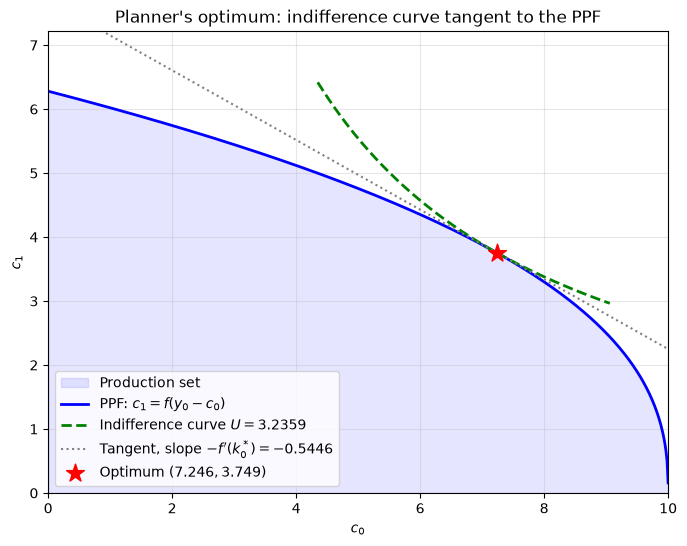

slope of PPF at optimum: -0.54457449   (finite diff -0.54457449)
slope of IC  at optimum: -0.54457449   (finite diff -0.54457449)
tangency error |MRS - MRT| = 1.110e-16


In [12]:
# PPF grid
c0_vals = np.linspace(0.001, y0 - 0.001, 600)
ppf = f(y0 - c0_vals)

# Separate, economically relevant range for the indifference curve
# so the log-utility asymptote near c0=0 does not distort the graph.
c0_indiff3 = np.linspace(0.6 * c0_star3, 1.25 * c0_star3, 600)
c1_indiff3 = np.exp((U_star3 - np.log(c0_indiff3)) / beta3)

# Supporting tangent through the optimum: slope -f'(k0*)
slope = fprime(k_star)
tangent = c1_star3 - slope * (c0_vals - c0_star3)

plt.figure(figsize=(8, 6))
plt.fill_between(c0_vals, 0, ppf, color="blue", alpha=0.10, label="Production set")
plt.plot(c0_vals, ppf, color="blue", lw=2, label=r"PPF: $c_1=f(y_0-c_0)$")
plt.plot(c0_indiff3, c1_indiff3, color="green", ls="--", lw=2,
         label=rf"Indifference curve $U={U_star3:.4f}$")
plt.plot(c0_vals, tangent, color="gray", ls=":", lw=1.5,
         label=rf"Tangent, slope $-f'(k_0^*)=-{slope:.4f}$")
plt.scatter([c0_star3], [c1_star3], color="red", marker="*", s=180, zorder=5,
            label=rf"Optimum $({c0_star3:.3f},{c1_star3:.3f})$")

plt.xlim(0, y0)
plt.ylim(0, max(ppf) * 1.15)
plt.xlabel(r"$c_0$")
plt.ylabel(r"$c_1$")
plt.title(r"Planner's optimum: indifference curve tangent to the PPF")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

# Slopes at the optimum, analytically and by finite difference
h = 1e-6
slope_ppf_fd = (f(y0 - (c0_star3 + h)) - f(y0 - (c0_star3 - h))) / (2 * h)
slope_ic_fd = (np.exp((U_star3 - np.log(c0_star3 + h)) / beta3)
               - np.exp((U_star3 - np.log(c0_star3 - h)) / beta3)) / (2 * h)

print(f"slope of PPF at optimum: {-fprime(k_star):.8f}   (finite diff {slope_ppf_fd:.8f})")
print(f"slope of IC  at optimum: {-c1_star3/(beta3*c0_star3):.8f}   (finite diff {slope_ic_fd:.8f})")
print(f"tangency error |MRS - MRT| = {abs(c1_star3/(beta3*c0_star3) - fprime(k_star)):.3e}")

Both slopes equal $-0.5445745$ at the optimum, so the dashed line is tangent to the PPF and to the indifference curve at the same point. That one line is the supporting price line, and its slope is the shadow price that Problem 4 turns into a market interest rate.

Worth flagging: $f'(k_0^*) = 0.5446 < 1$, so the implied net rate is negative. Not a bug — $y_0 = 10$ is large relative to what this technology can do with it, so the last unit invested has a low marginal product. The planner still invests, because $\log$ utility makes $c_1 = 0$ unthinkable.

### (e)
Vary $\beta$ from 0.50 to 1.00. Compute and plot optimal investment $k_0^*(\beta)$. Explain the economics and discuss monotonicity.

max |analytical - numerical| over the grid: 1.650e-06


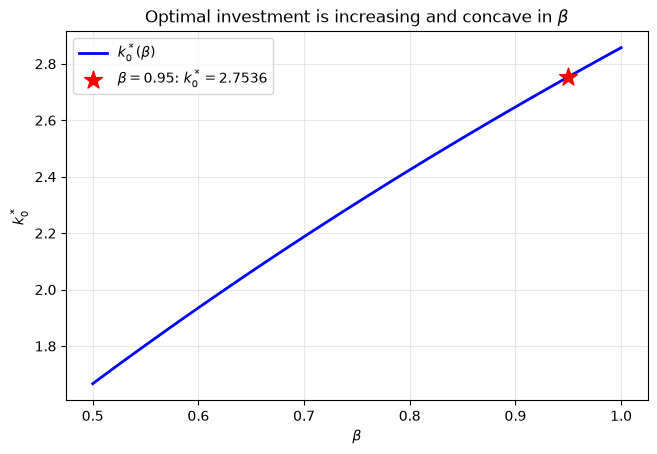


  beta       k0*       c0*       c1*    k0*/y0      f(k0*)
  0.50    1.6667    8.3333    3.0668    0.1667      0.7360
  0.70    2.1875    7.8125    3.4192    0.2188      0.6252
  0.90    2.6471    7.3529    3.6902    0.2647      0.5576
  0.95    2.7536    7.2464    3.7489    0.2754      0.5446
  1.00    2.8571    7.1429    3.8046    0.2857      0.5326


In [13]:
beta_grid = np.linspace(0.50, 1.00, 100)

# Analytical, plus a numerical re-solve at each beta as a check
k_of_beta = alpha * beta_grid * y0 / (1 + alpha * beta_grid)

k_of_beta_num = np.empty_like(beta_grid)
for i, b in enumerate(beta_grid):
    g = lambda k, b=b: np.inf if (k <= 0 or k >= y0) else -U(y0 - k, f(k), b)
    k_of_beta_num[i] = minimize_scalar(g, bounds=(1e-10, y0 - 1e-10), method="bounded").x

print(f"max |analytical - numerical| over the grid: {np.max(np.abs(k_of_beta - k_of_beta_num)):.3e}")

plt.figure(figsize=(7.5, 4.8))
plt.plot(beta_grid, k_of_beta, lw=2, color="blue", label=r"$k_0^*(\beta)$")
plt.scatter([beta3], [k_star], color="red", marker="*", s=180, zorder=5,
            label=rf"$\beta={beta3}$: $k_0^*={k_star:.4f}$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$k_0^*$")
plt.title(r"Optimal investment is increasing and concave in $\beta$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n{'beta':>6}{'k0*':>10}{'c0*':>10}{'c1*':>10}{'k0*/y0':>10}{'f(k0*)':>12}")
for b in (0.50, 0.70, 0.90, 0.95, 1.00):
    kb = alpha * b * y0 / (1 + alpha * b)
    print(f"{b:>6.2f}{kb:>10.4f}{y0-kb:>10.4f}{f(kb):>10.4f}{kb/y0:>10.4f}{fprime(kb):>12.4f}")

$$
k_0^*(\beta) = \frac{\alpha\beta\, y_0}{1 + \alpha\beta}
\qquad \Longrightarrow \qquad
\frac{dk_0^*}{d\beta} = \frac{\alpha y_0}{(1+\alpha\beta)^2} > 0,
$$

so investment is **strictly increasing** in $\beta$ everywhere on the grid — it climbs from $1.667$ at $\beta=0.5$ to $2.857$ at $\beta=1$, i.e. from $16.7\%$ to $28.6\%$ of $y_0$. The second derivative is negative, so the curve is concave.

A higher $\beta$ means more patience: more weight on $\log c_1$, and investment is the only way to move resources forward, so more of it. The FOC gives the same story from the price side — $f'(k_0^*) = c_1^*/(\beta c_0^*)$, so a larger $\beta$ lowers the return the planner requires, and since $f'$ is decreasing that means a larger $k_0^*$. Patient economies end up with more capital and lower interest rates.

Two things that are easy to miss. First, even at $\beta = 1$ investment stops well short of everything: log utility makes $c_0 = 0$ infinitely costly, so impatience is not the only thing limiting capital. Second, $A$ never appears in $k_0^*$ — under log utility and Cobb–Douglas the income and substitution effects of higher productivity cancel exactly in the investment *rate*.

# Problem 4. Decentralizing the Planner's Allocation

Now production is carried out by a competitive firm and consumption is chosen by a competitive consumer.


The pieces: a household that owns the date-0 endowment $y_0$ *and* owns the firm, a firm with the technology $f$, and a credit market with gross rate $R$. Both agents take $R$ as given.

At date 0 the household consumes $c_0$ and lends $s = y_0 - c_0$; the firm borrows $k_0$ and invests it. At date 1 the firm produces $f(k_0)$, repays $R k_0$, and pays the rest out as a dividend to the household. Credit market clearing is $s = k_0$.

### (a)
Derive the firm's first-order condition from its present-value profit-maximization problem.

The firm borrows $k_0$ today and sells $f(k_0)$ tomorrow, so its present-value profit is
$$
\pi(k_0) = -k_0 + \frac{f(k_0)}{R}.
$$
This is strictly concave in $k_0$ (since $\alpha < 1$), so the FOC is necessary and sufficient:
$$
\pi'(k_0) = -1 + \frac{f'(k_0)}{R} = 0
\qquad \Longleftrightarrow \qquad
f'(k_0) = R
\qquad \Longleftrightarrow \qquad
k^d(R) = \left(\frac{A\alpha}{R}\right)^{\frac{1}{1-\alpha}}.
$$

Invest until the marginal product of capital equals the cost of funds. Because $f'$ is decreasing, this pins down a unique $k_0$ for each $R$ and capital demand slopes downward.

One detail that matters later: profit at the optimum is not zero. Using $f(k)/f'(k) = k/\alpha$ for Cobb–Douglas,
$$
\pi(k^d) = -k^d + \frac{f(k^d)}{f'(k^d)} = \frac{1-\alpha}{\alpha}\, k^d > 0,
$$
because $f$ has decreasing returns in its single input. That profit goes to the household, which owns the firm, so it has to be counted in household wealth.

### (b)
Using the planner's $k_0^*$, calculate $R^*=f'(k_0^*)$ and $r^*=R^*-1$.

In [14]:
R_star = fprime(k_star)
r_star = R_star - 1.0

print(f"k0*          = {k_star:.6f}")
print(f"R* = f'(k0*) = {R_star:.10f}")
print(f"r* = R* - 1  = {r_star:.10f}   ({r_star:.2%})")

# Check: the firm's capital demand at R* should hand back exactly k0*
k_demand = (Aprod * alpha / R_star) ** (1 / (1 - alpha))
print(f"\nk^d(R*)      = {k_demand:.10f}   vs k0* = {k_star:.10f}   diff = {abs(k_demand-k_star):.3e}")

k0*          = 2.753623
R* = f'(k0*) = 0.5445744906
r* = R* - 1  = -0.4554255094   (-45.54%)

k^d(R*)      = 2.7536231884   vs k0* = 2.7536231884   diff = 4.441e-16


### (c)
Take $R^*$ as given. Compute firm profits, household wealth, and the household's optimal consumption bundle. Show that it coincides with the planner allocation.

In [15]:
# 1. firm at R*
k_firm = (Aprod * alpha / R_star) ** (1 / (1 - alpha))
profit = -k_firm + f(k_firm) / R_star          # PV profit, should equal (1-alpha)/alpha * k
dividend = f(k_firm) - R_star * k_firm         # date-1 payout

print("Firm:")
print(f"  k^d(R*)  = {k_firm:.6f}")
print(f"  output   = {f(k_firm):.6f}")
print(f"  repay Rk = {R_star * k_firm:.6f}")
print(f"  dividend = {dividend:.6f}")
print(f"  PV profit= {profit:.6f}   (check (1-a)/a*k = {(1-alpha)/alpha*k_firm:.6f})")

# 2. household wealth: endowment plus the PV of the firm it owns
W_h = y0 + profit
print(f"\nHousehold wealth W = y0 + profit = {y0:.4f} + {profit:.4f} = {W_h:.6f}")

# 3. household problem is just Problem 2 again, with W instead of the endowment
c0_h = W_h / (1 + beta3)
c1_h = beta3 * R_star * c0_h
s_h = y0 - c0_h

print(f"\nHousehold:")
print(f"  c0 = {c0_h:.6f}")
print(f"  c1 = {c1_h:.6f}")
print(f"  s  = y0 - c0 = {s_h:.6f}")

print(f"\n{'':<6}{'market':>14}{'planner':>14}{'|diff|':>12}")
for lab, mk, pl in (("c0", c0_h, c0_star3), ("c1", c1_h, c1_star3), ("k0", k_firm, k_star),
                    ("U", U(c0_h, c1_h, beta3), U_star3)):
    print(f"{lab:<6}{mk:>14.8f}{pl:>14.8f}{abs(mk - pl):>12.3e}")

print(f"\nMarket clearing: s - k = {s_h - k_firm:.3e},  y0 - c0 - k = {y0 - c0_h - k_firm:.3e},"
      f"  f(k) - c1 = {f(k_firm) - c1_h:.3e}")

Firm:
  k^d(R*)  = 2.753623
  output   = 3.748882
  repay Rk = 1.499553
  dividend = 2.249329
  PV profit= 4.130435   (check (1-a)/a*k = 4.130435)

Household wealth W = y0 + profit = 10.0000 + 4.1304 = 14.130435

Household:
  c0 = 7.246377
  c1 = 3.748882
  s  = y0 - c0 = 2.753623

              market       planner      |diff|
c0        7.24637681    7.24637681   0.000e+00
c1        3.74888236    3.74888236   8.882e-16
k0        2.75362319    2.75362319   4.441e-16
U         3.23588646    3.23588646   0.000e+00

Market clearing: s - k = 0.000e+00,  y0 - c0 - k = 0.000e+00,  f(k) - c1 = 0.000e+00


The decentralized allocation is the planner's allocation, to machine precision, and every market clears.

The algebra behind it: $W = y_0 + \frac{1-\alpha}{\alpha}k_0^* = y_0\frac{1+\beta}{1+\alpha\beta}$, so $c_0 = W/(1+\beta) = y_0/(1+\alpha\beta) = c_0^*$. The profit term is what makes it work — if the household did not own the firm, its wealth would be $y_0$ alone and it would consume too little.

### (d)
Verify numerically that $MRS=R^*=MRT$, and report numerical errors.

In [16]:
MRS_m = c1_h / (beta3 * c0_h)     # household side
MRT_m = fprime(k_firm)            # technology side

print(f"MRS = c1/(beta*c0) = {MRS_m:.14f}")
print(f"R*                 = {R_star:.14f}")
print(f"MRT = f'(k)        = {MRT_m:.14f}")
print(f"\n|MRS - R*|  = {abs(MRS_m - R_star):.3e}")
print(f"|MRT - R*|  = {abs(MRT_m - R_star):.3e}")
print(f"|MRS - MRT| = {abs(MRS_m - MRT_m):.3e}")

print("\nResiduals of the equilibrium conditions:")
print(f"  Euler   1/c0 - beta*R/c1 = {1/c0_h - beta3*R_star/c1_h:.3e}")
print(f"  firm    f'(k) - R        = {fprime(k_firm) - R_star:.3e}")
print(f"  budget  c0 + c1/R - W    = {c0_h + c1_h/R_star - W_h:.3e}")
print(f"  clearing s - k           = {s_h - k_firm:.3e}")
print(f"  vs planner |U - U*|      = {abs(U(c0_h, c1_h, beta3) - U_star3):.3e}")

MRS = c1/(beta*c0) = 0.54457449055565
R*                 = 0.54457449055565
MRT = f'(k)        = 0.54457449055565

|MRS - R*|  = 0.000e+00
|MRT - R*|  = 0.000e+00
|MRS - MRT| = 0.000e+00

Residuals of the equilibrium conditions:
  Euler   1/c0 - beta*R/c1 = 0.000e+00
  firm    f'(k) - R        = 0.000e+00
  budget  c0 + c1/R - W    = 0.000e+00
  clearing s - k           = 0.000e+00
  vs planner |U - U*|      = 0.000e+00


### (e)
Explain the planner's problem, consumer optimization, firm optimization, market clearing, and why the coincidence of allocations matters.

**The planner.** One agent, one problem, no prices. She compares $MRS$ with $MRT$ directly and equates them, giving $k_0^* = \frac{\alpha\beta y_0}{1+\alpha\beta}$. The Lagrange multipliers $\lambda_0, \lambda_1$ are shadow prices, and their ratio is $f'(k_0^*)$ — a price that only exists inside her head.

**The consumer.** A price taker who knows $R$, its endowment, and its dividend, and nothing at all about $A$ or $\alpha$. It maximizes $\log c_0 + \beta \log c_1$ subject to $c_0 + c_1/R = W$, which gives $MRS = R$ and a saving supply $s(R)$.

**The firm.** Also a price taker, and it knows nothing about $\beta$ or about preferences. It maximizes $-k_0 + f(k_0)/R$, which gives $MRT = f'(k_0) = R$ and an investment demand $k^d(R)$.

**Market clearing.** Equilibrium is a rate $R$ at which both optimize *and* $s(R) = k^d(R)$. With one credit market, the two goods markets then clear automatically by Walras's law — which is what the residuals in part (c) confirm.

**Why the coincidence matters.** The planner's single condition $MRS = MRT$ gets split into two halves, $MRS = R$ for the household and $MRT = R$ for the firm. Because both face the *same* $R$, the halves chain back together into $MRS = R = MRT$. That is the First Welfare Theorem in this economy: the price system carries all the information the planner had, even though no one in the decentralized economy knows more than their own problem plus one number.

# Problem 5. A Computational Experiment with Disequilibrium

Define
$$
Z(R)=k^d(R)-s(R).
$$


### (a)
Construct functions for firm investment, household saving, and $Z(R)$.

In [17]:
def firm_at_R(R):
    # Investment demand from f'(k) = R, plus output and PV profit
    k = (Aprod * alpha / R) ** (1 / (1 - alpha))
    return k, f(k), -k + f(k) / R

def household_at_R(R):
    # Household owns the firm, so profit is part of its wealth
    _, _, pi = firm_at_R(R)
    W = y0 + pi
    c0 = W / (1 + beta3)
    c1 = beta3 * R * c0
    return c0, c1, y0 - c0

def Z(R):
    # Excess demand for funds: investment minus saving
    return firm_at_R(R)[0] - household_at_R(R)[2]

for Rq in (0.35, 0.45, R_star, 0.75, 1.10):
    k, _, pi = firm_at_R(Rq)
    c0q, c1q, sq = household_at_R(Rq)
    tag = "   <- R*" if abs(Rq - R_star) < 1e-12 else ""
    print(f"R = {Rq:.4f}:  k^d = {k:8.5f}   s = {sq:8.5f}   Z = {Z(Rq):9.5f}{tag}")

R = 0.3500:  k^d =  5.75290   s =  0.44649   Z =   5.30641
R = 0.4500:  k^d =  3.78424   s =  1.96084   Z =   1.82341
R = 0.5446:  k^d =  2.75362   s =  2.75362   Z =   0.00000   <- R*
R = 0.7500:  k^d =  1.61522   s =  3.62932   Z =  -2.01410
R = 1.1000:  k^d =  0.85312   s =  4.21555   Z =  -3.36242


### (b)
Evaluate and plot $Z(R)$ on a sensible grid.

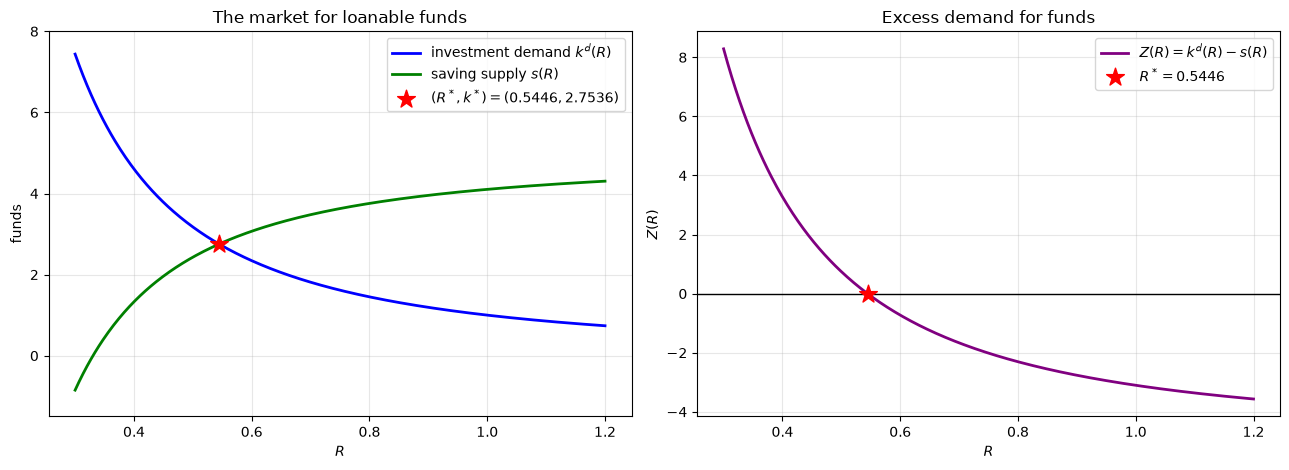

Z(0.30) = 8.287998  (excess demand)
Z(1.20) = -3.566178  (excess supply)
Z is monotone decreasing on the grid: True


In [18]:
Rz = np.linspace(0.3, 1.2, 400)
Zv = Z(Rz)
kd = firm_at_R(Rz)[0]
sv = household_at_R(Rz)[2]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(Rz, kd, lw=2, color="blue", label=r"investment demand $k^d(R)$")
ax[0].plot(Rz, sv, lw=2, color="green", label=r"saving supply $s(R)$")
ax[0].scatter([R_star], [k_star], color="red", marker="*", s=180, zorder=5,
              label=rf"$(R^*, k^*)=({R_star:.4f}, {k_star:.4f})$")
ax[0].set_ylim(-1.5, 8)
ax[0].set_ylabel("funds")
ax[0].set_title("The market for loanable funds")

ax[1].plot(Rz, Zv, lw=2, color="purple", label=r"$Z(R)=k^d(R)-s(R)$")
ax[1].axhline(0, color="black", lw=1)
ax[1].scatter([R_star], [0], color="red", marker="*", s=180, zorder=5,
              label=rf"$R^*={R_star:.4f}$")
ax[1].set_ylabel(r"$Z(R)$")
ax[1].set_title(r"Excess demand for funds")

for a in ax:
    a.set_xlabel(r"$R$")
    a.grid(True, alpha=0.3)
    a.legend()

fig.tight_layout()
plt.show()

print(f"Z(0.30) = {Z(0.30):.6f}  (excess demand)")
print(f"Z(1.20) = {Z(1.20):.6f}  (excess supply)")
print(f"Z is monotone decreasing on the grid: {bool(np.all(np.diff(Zv) < 0))}")

### (c)
Use a root-finding routine such as `brentq` to solve $Z(R)=0$. Explain why the root is an equilibrium.

In [19]:
# Z changes sign between 0.30 and 1.20, so that is the bracket
R_eq = brentq(Z, 0.30, 1.20)
k_eq, y1_eq, pi_eq = firm_at_R(R_eq)
c0_eq, c1_eq, s_eq = household_at_R(R_eq)

print(f"R_eq    = {R_eq:.12f}     r_eq = {R_eq - 1:.6f}")
print(f"Z(R_eq) = {Z(R_eq):.3e}")
print(f"\nk = {k_eq:.6f}, s = {s_eq:.6f}, c0 = {c0_eq:.6f}, c1 = {c1_eq:.6f}, U = {U(c0_eq, c1_eq, beta3):.6f}")

print("\nEquilibrium conditions:")
print(f"  Euler       1/c0 - beta*R/c1 = {1/c0_eq - beta3*R_eq/c1_eq:.3e}")
print(f"  firm FOC    f'(k) - R        = {fprime(k_eq) - R_eq:.3e}")
print(f"  credit      s - k            = {s_eq - k_eq:.3e}")
print(f"  goods t=0   y0 - c0 - k      = {y0 - c0_eq - k_eq:.3e}")
print(f"  goods t=1   f(k) - c1        = {y1_eq - c1_eq:.3e}")

R_eq    = 0.544574490556     r_eq = -0.455426
Z(R_eq) = -1.594e-13

k = 2.753623, s = 2.753623, c0 = 7.246377, c1 = 3.748882, U = 3.235886

Equilibrium conditions:
  Euler       1/c0 - beta*R/c1 = 0.000e+00
  firm FOC    f'(k) - R        = 0.000e+00
  credit      s - k            = 1.594e-13
  goods t=0   y0 - c0 - k      = 1.594e-13
  goods t=1   f(k) - c1        = -8.793e-14


The root is an equilibrium because $Z(R) = 0$ is precisely the missing condition. At any $R$ the firm is already on its demand curve and the household on its supply curve — both are optimizing by construction of `firm_at_R` and `household_at_R`. What is not automatic is that the two plans are *consistent*: the funds the firm wants to borrow have to be the funds the household wants to lend. $Z(R)=0$ imposes that, and once the credit market clears both goods markets clear too (the last two residuals above).

$Z$ is strictly decreasing — $k^d$ falls in $R$ and $s$ rises — so the root is unique and `brentq` on a bracket with a sign change is guaranteed to find it.

### (d)
Compare the market-clearing interest rate with $R^*=f'(k_0^*)$. Explain why they agree.

In [20]:
print(f"market-clearing rate  R_eq = {R_eq:.16f}")
print(f"planner shadow price  R*   = {R_star:.16f}")
print(f"|difference|               = {abs(R_eq - R_star):.3e}   (machine eps = {np.finfo(float).eps:.1e})")

market-clearing rate  R_eq = 0.5445744905556630
planner shadow price  R*   = 0.5445744905556522
|difference|               = 1.077e-14   (machine eps = 2.2e-16)


They agree to about $10^{-14}$, i.e. to the tolerance of the root-finder, and it is not a numerical accident. In equilibrium the firm sets $f'(k) = R$ and the household sets $MRS = R$; clearing forces $s = k$, so the same $k$ appears in both. Substituting the market-clearing quantity back in gives $MRS = f'(k)$, which is exactly the planner's FOC — and that has a unique solution $k_0^*$. So the equilibrium quantity has to be $k_0^*$, and the price that supports it has to be $f'(k_0^*) = R^*$.

Put differently, $R^*$ was already the planner's shadow price $\lambda_0/\lambda_1$. The market does not discover a new number; it makes the planner's internal price public.

### (e)
Choose $R_L<R^*$ and $R_H>R^*$. Report saving and investment and interpret the imbalance.

In [21]:
R_L, R_H = 0.40, 0.80

print(f"{'':<20}{'R_L = 0.40':>14}{'R* (clears)':>14}{'R_H = 0.80':>14}")
rows = []
for Rq in (R_L, R_star, R_H):
    k, _, _ = firm_at_R(Rq)
    _, _, sq = household_at_R(Rq)
    rows.append((k, sq, k - sq))

for i, lab in enumerate(["investment k^d(R)", "saving s(R)", "excess demand Z(R)"]):
    print(f"{lab:<20}" + "".join(f"{rows[j][i]:>14.6f}" for j in range(3)))

print(f"\nAt R_L: Z = {Z(R_L):+.4f}, firms want more funds than households will lend -> R must rise.")
print(f"At R_H: Z = {Z(R_H):+.4f}, households want to lend more than firms will borrow -> R must fall.")

                        R_L = 0.40   R* (clears)    R_H = 0.80
investment k^d(R)         4.605039      2.753623      1.450497
saving s(R)               1.329457      2.753623      3.756028
excess demand Z(R)        3.275582      0.000000     -2.305532

At R_L: Z = +3.2756, firms want more funds than households will lend -> R must rise.
At R_H: Z = -2.3055, households want to lend more than firms will borrow -> R must fall.


At $R_L = 0.40$ borrowing is cheap, so the firm wants $k^d = 4.61$ while the household only wants to lend $1.33$ — excess demand of $3.28$. Someone's plan cannot be carried out; the rationed borrowers bid the rate up.

At $R_H = 0.80$ the reverse: lending is attractive and investing is not, so saving of $3.76$ chases investment demand of $1.45$. Unmatched lenders accept a lower rate.

Only at $R^*$ are the two sides describing the same trade, and that is also the only rate at which $MRS = R = MRT$ — away from $R^*$ the household's willingness to substitute and the technology's ability to substitute are being equated to a price that no quantity actually supports.

# Problem 6. The First Welfare Theorem — What the Computer Does Not Prove


### (a)
Generate 100,000 random feasible allocations and compare the best one with the planner optimum.

In [22]:
rng = np.random.default_rng(5040)
N = 100_000

# 1. feasible investment
k_rand = rng.uniform(1e-9, y0 - 1e-9, N)

# 2. feasible c0 and c1 given k0. Feasibility only needs c0 <= y0-k and c1 <= f(k),
#    so scale each ceiling by an independent uniform draw (i.e. allow waste).
c0_rand = rng.uniform(0, 1, N) * (y0 - k_rand)
c1_rand = rng.uniform(0, 1, N) * f(k_rand)

# 3. evaluate utility
Ur = U(c0_rand, c1_rand, beta3)
best = Ur.argmax()

# 4. compare with the planner
print(f"best of {N:,} random feasible allocations: U = {Ur[best]:.6f}")
print(f"  at (c0, c1, k0) = ({c0_rand[best]:.4f}, {c1_rand[best]:.4f}, {k_rand[best]:.4f})")
print(f"planner:  U* = {U_star3:.6f} at ({c0_star3:.4f}, {c1_star3:.4f}, {k_star:.4f})")
print(f"shortfall U* - best = {U_star3 - Ur[best]:.6e}")
print(f"any draw beats the planner? {bool(np.any(Ur > U_star3))}")

# A harder test: draws on the frontier, so only k0 is random and nothing is wasted
Uf = U(y0 - k_rand, f(k_rand), beta3)
print(f"\nbest frontier draw: U = {Uf.max():.10f} at k0 = {k_rand[Uf.argmax()]:.6f}")
print(f"shortfall U* - best = {U_star3 - Uf.max():.3e},  |k - k0*| = {abs(k_rand[Uf.argmax()] - k_star):.3e}")

print("\nbest-so-far as N grows (frontier draws):")
for m in (10, 100, 1_000, 10_000, 100_000):
    print(f"  N = {m:>7,}:  U = {Uf[:m].max():.8f},  gap = {U_star3 - Uf[:m].max():.3e}")

best of 100,000 random feasible allocations: U = 3.207339
  at (c0, c1, k0) = (7.1392, 3.6954, 2.7359)
planner:  U* = 3.235886 at (7.2464, 3.7489, 2.7536)
shortfall U* - best = 2.854795e-02
any draw beats the planner? False

best frontier draw: U = 3.2358864648 at k0 = 2.753608
shortfall U* - best = 8.494e-12,  |k - k0*| = 1.567e-05

best-so-far as N grows (frontier draws):
  N =      10:  U = 3.23456701,  gap = 1.319e-03
  N =     100:  U = 3.23572224,  gap = 1.642e-04
  N =   1,000:  U = 3.23587661,  gap = 9.858e-06
  N =  10,000:  U = 3.23588646,  gap = 8.315e-10
  N = 100,000:  U = 3.23588646,  gap = 8.494e-12


### (b)
Does this prove global optimality? Explain.

No. Random search shows that none of 100,000 particular points beat the planner, which is evidence, not proof. The feasible set is a continuum, so a finite sample covers none of it in any meaningful sense — and the table above makes the point: the utility gap shrinks roughly like a power of $N$ and never actually reaches zero. Sampling more would narrow the gap, never close it.

What does prove global optimality is the structure: the reduced objective $G(k_0) = \log(y_0-k_0) + \alpha\beta\log k_0 + \beta\log A$ is strictly concave on $(0, y_0)$ and tends to $-\infty$ at both ends, so its unique stationary point is the global maximum. The computation is a sanity check on that argument, not a substitute for it.

### (c)
Does numerical coincidence prove the First Welfare Theorem? Explain.

No. All the numerical agreement in Problem 4 shows is that *for this parameterization* the two allocations happen to coincide to 15 decimal places. That is consistent with the theorem, and it would have flagged an algebra error if there were one, but it cannot rule out the possibility that the match depends on $\log$ utility, or Cobb–Douglas, or these particular numbers.

The theorem is a general statement with a general proof: given complete markets, price-taking, no externalities and locally non-satiated preferences, *any* competitive equilibrium is Pareto efficient — and the proof is a two-line contradiction argument about budget sets, not a computation. Checking one point of a claim quantified over all economies is not proving the claim.

### (d)
State the First Welfare Theorem and explain Pareto efficiency in this one-consumer economy.

**First Welfare Theorem.** If households' preferences are locally non-satiated, markets are complete and competitive (everyone takes prices as given), and there are no externalities, then every competitive equilibrium allocation is Pareto efficient.

*Sketch:* suppose some feasible allocation made everyone at least as well off and someone strictly better off. Anything strictly preferred to the equilibrium bundle must cost strictly more than that household's wealth, and anything weakly preferred must cost at least as much (local non-satiation). Summing over households, the alternative costs strictly more than total wealth — so it is not feasible. Contradiction.

**Here.** With one consumer, Pareto efficiency is just: no feasible allocation gives higher $U$. So the efficient allocation *is* the planner's solution, and the theorem reduces to the statement we verified — the competitive equilibrium $(c_0, c_1, k_0)$ maximizes $U$ over the feasible set. This is the cleanest possible case, since there is no distribution question at all: with many agents, efficiency would only mean you cannot help one without hurting another, and there would be many efficient allocations, one per set of weights.

### (e)
Explain why the slogan “markets are efficient” is too loose. Mention at least two relevant assumptions or qualifications.

"Markets are efficient" is a compressed version of a theorem with hypotheses, and the hypotheses do the work. Two that matter most:

- **Complete markets and price-taking.** The result needs a market for every good, including every date and state, and agents small enough to treat prices as given. Here that is one credit market and two agents assumed competitive. Remove it — market power, missing insurance markets, borrowing constraints — and the equilibrium generally is not efficient.
- **No externalities and full information.** Every effect of an action has to be priced. Pollution, congestion, knowledge spillovers, or asymmetric information (adverse selection, moral hazard) all break the link between private and social returns, and the equilibrium stops maximizing anything.

And the word "efficient" is narrower than it sounds. Pareto efficiency says no one can be made better off without hurting someone else; it says nothing about whether the outcome is fair. An allocation where one agent has everything is Pareto efficient. In this one-agent economy that distinction is invisible, which is exactly why the one-agent model is a bad place to form intuitions about the slogan.

# Problem 7. Synthesis

Write approximately 500 words answering:

> In this two-period economy, what economic role is played by the gross real interest rate?

Your answer should explain the connection among preferences, technology, prices, optimization, market clearing, and Pareto efficiency, and the meaning of

$$
\boxed{MRS=R=MRT.}
$$


The gross real interest rate $R$ is the price of goods today in terms of goods tomorrow. Everything else in this economy is a quantity — endowments, capital, consumption — and $R$ is the single number that makes those quantities mutually consistent.

Start with preferences. The household's willingness to postpone consumption is summarized by $MRS_{0,1} = c_1/(\beta c_0)$: how many units of tomorrow it demands to give up one unit of today. It rises with impatience (small $\beta$) and with how lopsided the consumption profile already is. Facing a price $R$, the household equates its willingness to the price and stops there, $MRS = R$ — the Euler equation. That gives a saving supply $s(R)$: at a high $R$ waiting is well paid and it lends, at a low $R$ it borrows. In Problem 2, with no technology at all, the same logic produced $\widehat{R} = e_1/(\beta e_0)$, the rate at which the household's own $MRS$ at its endowment equals the market price and it trades nothing.

Technology enters the same way from the other side. The economy's *ability* to move goods forward in time is $MRT_{0,1} = f'(k_0)$ — the extra output tomorrow from one less unit eaten today. The firm compares that ability to the price of funds and invests until $f'(k_0) = R$, giving a capital demand $k^d(R)$ that slopes down because of diminishing returns.

So $R$ appears twice, in two completely separate problems solved by agents who know nothing about each other. The household knows $R$, its wealth, and its own preferences; it has never heard of $\alpha$ or $A$. The firm knows $R$ and its technology; it has never heard of $\beta$. What links them is market clearing: the funds lent must be the funds borrowed, $s(R) = k^d(R)$. That is one equation in one unknown, and solving it — numerically, `brentq` on $Z(R) = k^d(R) - s(R)$ — pins down $R^*$.

Once $R$ takes the value that clears the market, the two conditions chain:

$$MRS = R = MRT.$$

Read left to right, this says the rate at which the household is *willing* to substitute equals the rate at which the economy is *able* to. That is exactly the planner's first-order condition, derived in Problem 3 with no prices anywhere. The equilibrium therefore reproduces the planner's allocation, which is the First Welfare Theorem in this economy — and the numbers confirm it to 15 decimal places, with $R^* = f'(k_0^*) = 0.5446$ appearing both as the planner's shadow price $\lambda_0/\lambda_1$ and as the market rate.

The economics of the equality is worth stating plainly. If $MRS > MRT$, the household values future goods by more than the technology can deliver, so the economy is over-investing and should eat more today; if $MRS < MRT$, it is under-investing. Only at equality is there no reallocation left that anyone would want. Geometrically it is a single tangency: the indifference curve touches the PPF, and the line tangent to both is simultaneously the budget line, the isoprofit line, and the price line, with slope $-R^*$. One line, three interpretations.

So $R$ is not just "the return on saving." It is the decentralizing device: the one price that carries the planner's information to agents who do not have it, and the reason a collection of selfish, ignorant, uncoordinated optimizations produces the allocation a benevolent planner with full knowledge would have chosen.

# What surprised me?

Identify one result from the assignment that was not obvious to you before doing the computations. Explain what you now understand differently.


The negative net interest rate. $R^* = 0.5446$, so $r^* = -45.5\%$ — the economy invests $2.75$ units and gets back $3.75$, but the *marginal* unit loses value, and the equilibrium price of moving goods forward in time is a discount rather than a premium. I had been carrying around the assumption that a negative real rate signals something broken. It doesn't. It just says date-0 goods are abundant ($y_0 = 10$) relative to what this technology can do with them, and log utility makes the household desperate enough about $c_1 = 0$ that it keeps investing anyway. The interest rate is a relative price of two dated goods, and like any relative price it goes wherever scarcity puts it.

The other thing I did not expect was how much work firm ownership does in Problem 4. Decreasing returns in $k$ mean profit is strictly positive, $\frac{1-\alpha}{\alpha}k_0^* = 4.13$ — bigger than a third of the endowment. Drop that from household wealth and the decentralized allocation misses the planner's by a lot. The First Welfare Theorem needs *all* the income to get back to the households; it is easy to write down the household budget constraint without the profit term and never notice why it fails.